# VAC Forming Scrap Root Cause Analysis & Recommendations
**Project:** IAC VAC Forming Scrap Reduction  
**Prepared by:** Algo8 AI Team  
**Date:** 13 March 2026  
**Data Period:** 4 Feb 2026 – 5 Mar 2026

---
## 1. Problem Statement

The IAC VAC forming line produces automotive interior parts (door panels, map pockets, glove box outers) by vacuum-forming vinyl over plastic substrates. The process involves **Roll Coating → Grippers/Clamp Frame → Oven Heating → Vacuum Pressing**.

**Current scrap rate is 8.15%** (349 scrapped parts out of 4,283 produced), with each scrapped part costing approximately **\$67** (\$52 vinyl + \$16 plastic). This amounts to an estimated **\$23,383 in losses** over one month of production.

The objective is **not prediction** — the line already detects scrap in real-time. Instead, the goal is to:
1. **Diagnose** which process parameters are deviating when a specific defect type occurs
2. **Recommend** actionable parameter adjustments (e.g., "increase BHT temperature", "widen roller gap") to operators
3. **Build operating windows** for each parameter that minimize defect probability

---
## 2. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')

# Load data
process_raw = pd.read_excel('Book3.xlsx', sheet_name='Process Data')
scrap_raw = pd.read_excel('Book3.xlsx', sheet_name='Scrap')

print(f"Process records: {len(process_raw):,}")
print(f"Scrap records:   {len(scrap_raw):,}")
print(f"Date range:      {process_raw['built_time'].min().date()} to {process_raw['built_time'].max().date()}")

Process records: 4,283
Scrap records:   349
Date range:      2026-02-04 to 2026-03-05


### 2.1 Parse Machine Parameters
The raw data stores 40 machine parameters as comma-separated key:value strings in DS1, DS2, DS3 columns. We parse these into individual numeric columns.

In [2]:
def parse_params(val):
    pairs = {}
    if pd.notna(val):
        for item in str(val).split(','):
            if ':' in item:
                k, v = item.rsplit(':', 1)
                try:
                    pairs[k.strip()] = float(v.strip())
                except ValueError:
                    pass
    return pairs

ds1 = process_raw['DS1'].apply(parse_params).apply(pd.Series)
ds2 = process_raw['DS2'].apply(parse_params).apply(pd.Series)
ds3 = process_raw['DS3'].apply(parse_params).apply(pd.Series)

df = pd.concat([process_raw[['ID', 'part_desc', 'built_time']], ds1, ds2, ds3], axis=1)

# Merge scrap labels
df = df.merge(scrap_raw[['wip_part_id', 'description']], 
              left_on='ID', right_on='wip_part_id', how='left')
df['description'] = df['description'].fillna('Good')
df.drop(columns=['wip_part_id'], inplace=True)

print(f"Parsed {len(ds1.columns) + len(ds2.columns) + len(ds3.columns)} machine parameters")
print(f"\nFinal dataset shape: {df.shape}")
df.head(3)

Parsed 40 machine parameters

Final dataset shape: (4283, 44)


,ID,part_desc,built_time,Temp. THT at Trigger,Temp. BHT at Trigger,heating time (tens of seconds),Vacuum Time Tool Cavity A,Vacuum Time Tool Cavity B,BT Circuit 1 Temp,BT Circuit 2 Temp,...,Stretch Cross Stretch 1,Stretch Cross Stretch 2,Stretch Cross Stretch 3,Stretch Cross Form,Pick Material Pos,Temp Z1,Temp Z2,Temp Z3,Temp Z4,description
0,8751414,PS LOWER RHD WHITE,2026-03-05 15:27:24.000,170.0,191.0,533.0,74.0,74.0,24.0,0.0,...,4820.0,4840.0,4860.0,4880.0,220.0,174.0,171.0,167.0,0.0,Good
1,8751413,DS LOWER RHD WHITE,2026-03-05 15:27:18.063,170.0,191.0,533.0,74.0,74.0,24.0,0.0,...,4820.0,4840.0,4860.0,4880.0,220.0,174.0,171.0,167.0,0.0,Good
2,8751407,GB OUTER RHD WHITE,2026-03-05 15:27:09.427,170.0,191.0,533.0,74.0,74.0,24.0,0.0,...,4820.0,4840.0,4860.0,4880.0,220.0,174.0,171.0,167.0,0.0,Good


In [26]:
df.columns

Index(['ID', 'part_desc', 'built_time', 'Temp. THT at Trigger',
       'Temp. BHT at Trigger', 'heating time (tens of seconds)',
       'Vacuum Time Tool Cavity A', 'Vacuum Time Tool Cavity B',
       'BT Circuit 1 Temp', 'BT Circuit 2 Temp', 'TTF Circuit 1 Temp',
       'TTF Circuit 2 Temp', 'Graining Vacuum TTF Cavity 1',
       'Graining Vacuum TTF Cavity 2', 'Machine Cycle Time', 'Tool Number',
       'Capacity THT', 'Capacity BHT', 'Time Feed to Vacuum 1', 'Pyro Clean',
       'Top Tool Pos Close', 'Pos Vinyl N Length', 'Pos Vinyl N Width',
       'Pos Vinyl S Length', 'Pos Vinyl S Width', 'Roller Gap LH',
       'Roller Gap RH', 'Glue Temp', 'Stetch Length Pick Up',
       'Stetch Length Stretch 1', 'Stetch Length Stretch 2',
       'Stetch Length Stretch 3', 'Stetch Length Form',
       'Stretch Cross Pick Up', 'Stretch Cross Stretch 1',
       'Stretch Cross Stretch 2', 'Stretch Cross Stretch 3',
       'Stretch Cross Form', 'Pick Material Pos', 'Temp Z1', 'Temp Z2',
       'Te

### 2.2 Define Process Sections & Parameter Mapping
Parameters are grouped by the physical section of the VAC forming line they belong to.

In [3]:
# Section-wise parameter mapping (from process documentation)
SECTIONS = {
    'Roll Coating': {
        'params': ['Roller Gap LH', 'Roller Gap RH', 'Glue Temp', 'Pick Material Pos'],
        'influences': 'Glue thickness, adhesion quality, glue distribution'
    },
    'Grippers & Clamp Frame': {
        'params': ['Pos Vinyl N Length', 'Pos Vinyl N Width', 'Pos Vinyl S Length', 'Pos Vinyl S Width',
                   'Stetch Length Pick Up', 'Stetch Length Stretch 1', 'Stetch Length Stretch 2',
                   'Stetch Length Stretch 3', 'Stetch Length Form',
                   'Stretch Cross Pick Up', 'Stretch Cross Stretch 1', 'Stretch Cross Stretch 2',
                   'Stretch Cross Stretch 3', 'Stretch Cross Form', 'Top Tool Pos Close'],
        'influences': 'Wrinkles, material distribution, stretching uniformity'
    },
    'Oven': {
        'params': ['Temp. THT at Trigger', 'Temp. BHT at Trigger', 'Temp Z1', 'Temp Z2', 'Temp Z3', 'Temp Z4',
                   'heating time (tens of seconds)', 'Capacity THT', 'Capacity BHT'],
        'influences': 'Vinyl softness, stretchability, burn or wrinkle defects'
    },
    'Vacuum Press': {
        'params': ['Vacuum Time Tool Cavity A', 'Vacuum Time Tool Cavity B',
                   'Graining Vacuum TTF Cavity 1', 'Graining Vacuum TTF Cavity 2'],
        'influences': 'Forming quality, surface texture, dimensional accuracy'
    },
    'Machine / Other': {
        'params': ['Machine Cycle Time', 'Tool Number', 'Pyro Clean',
                   'BT Circuit 1 Temp', 'BT Circuit 2 Temp',
                   'TTF Circuit 1 Temp', 'TTF Circuit 2 Temp', 'Time Feed to Vacuum 1'],
        'influences': 'Overall cycle control, tool condition, circuit temperatures'
    }
}

# Process-related defects (in scope per MoM)
PROCESS_DEFECTS = [
    'Low Glue/Read Thru/Impression', 'Wrinkle', 'Dent', 'Bumps / lumps',
    'Out of dimension', 'Burnt Carpet / Vynil', 'Water stain',
    'Glue bleed thru', 'Short material / shot'
]

# Non-process defects (excluded from analysis)
NON_PROCESS_DEFECTS = ['Bad edge wrap', 'Broken / Fracture', 'Hole']

# Label data
df['defect_scope'] = df['description'].apply(
    lambda x: 'Good' if x == 'Good' 
    else ('Process Defect' if x in PROCESS_DEFECTS else 'Non-Process Defect'))

all_params = [p for s in SECTIONS.values() for p in s['params']]

print("Parameter sections defined:")
for sec, info in SECTIONS.items():
    print(f"  {sec}: {len(info['params'])} params → {info['influences']}")

Parameter sections defined:
  Roll Coating: 4 params → Glue thickness, adhesion quality, glue distribution
  Grippers & Clamp Frame: 15 params → Wrinkles, material distribution, stretching uniformity
  Oven: 9 params → Vinyl softness, stretchability, burn or wrinkle defects
  Vacuum Press: 4 params → Forming quality, surface texture, dimensional accuracy
  Machine / Other: 8 params → Overall cycle control, tool condition, circuit temperatures


---
## 3. Data Overview & Scrap Distribution

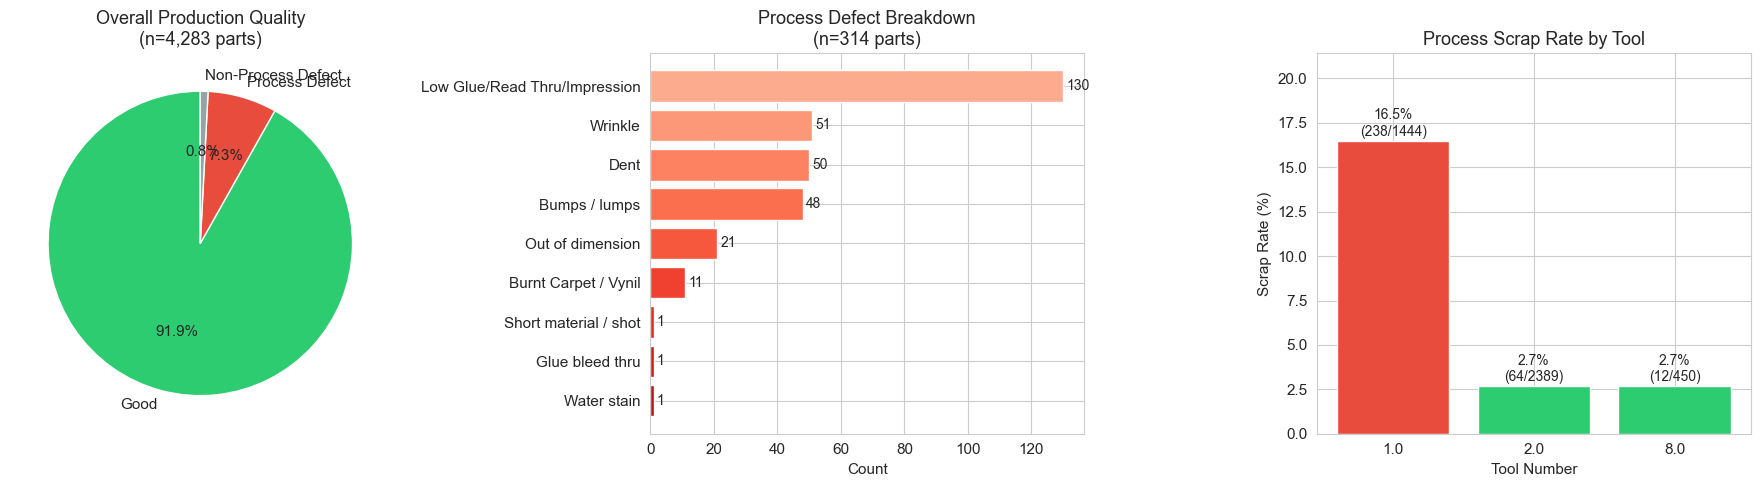


Key Numbers:
  Total production:     4,283 parts
  Process scrap:        314 parts (7.3%)
  Non-process scrap:    35 parts (excluded from analysis)
  Estimated monthly loss: $21,038


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3a. Overall scrap breakdown
scope_counts = df['defect_scope'].value_counts()
colors_scope = {'Good': '#2ecc71', 'Process Defect': '#e74c3c', 'Non-Process Defect': '#95a5a6'}
axes[0].pie(scope_counts.values, labels=scope_counts.index, autopct='%1.1f%%',
            colors=[colors_scope[x] for x in scope_counts.index], startangle=90,
            textprops={'fontsize': 11})
axes[0].set_title(f'Overall Production Quality\n(n={len(df):,} parts)')

# 3b. Defect type distribution (process-related only)
process_scrap = df[df['defect_scope'] == 'Process Defect']['description'].value_counts()
colors_bar = plt.cm.Reds(np.linspace(0.3, 0.8, len(process_scrap)))
bars = axes[1].barh(process_scrap.index[::-1], process_scrap.values[::-1], color=colors_bar[::-1])
for bar, val in zip(bars, process_scrap.values[::-1]):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                str(val), va='center', fontsize=10)
axes[1].set_title(f'Process Defect Breakdown\n(n={process_scrap.sum()} parts)')
axes[1].set_xlabel('Count')

# 3c. Scrap rate by Tool Number
tool_stats = df.groupby('Tool Number').agg(
    total=('ID', 'count'),
    scrap=('defect_scope', lambda x: (x == 'Process Defect').sum())
).reset_index()
tool_stats['rate'] = tool_stats['scrap'] / tool_stats['total'] * 100
tool_colors = ['#e74c3c' if r > 10 else '#f39c12' if r > 5 else '#2ecc71' for r in tool_stats['rate']]
bars = axes[2].bar(tool_stats['Tool Number'].astype(str), tool_stats['rate'], color=tool_colors)
for bar, row in zip(bars, tool_stats.itertuples()):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{row.rate:.1f}%\n({row.scrap}/{row.total})', ha='center', fontsize=10)
axes[2].set_title('Process Scrap Rate by Tool')
axes[2].set_xlabel('Tool Number')
axes[2].set_ylabel('Scrap Rate (%)')
axes[2].set_ylim(0, max(tool_stats['rate']) * 1.3)

plt.tight_layout()
plt.savefig('01_scrap_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey Numbers:")
print(f"  Total production:     {len(df):,} parts")
print(f"  Process scrap:        {(df['defect_scope']=='Process Defect').sum()} parts ({(df['defect_scope']=='Process Defect').mean()*100:.1f}%)")
print(f"  Non-process scrap:    {(df['defect_scope']=='Non-Process Defect').sum()} parts (excluded from analysis)")
print(f"  Estimated monthly loss: ${(df['defect_scope']=='Process Defect').sum() * 67:,}")

### 3.1 Scrap Rate by Part Type

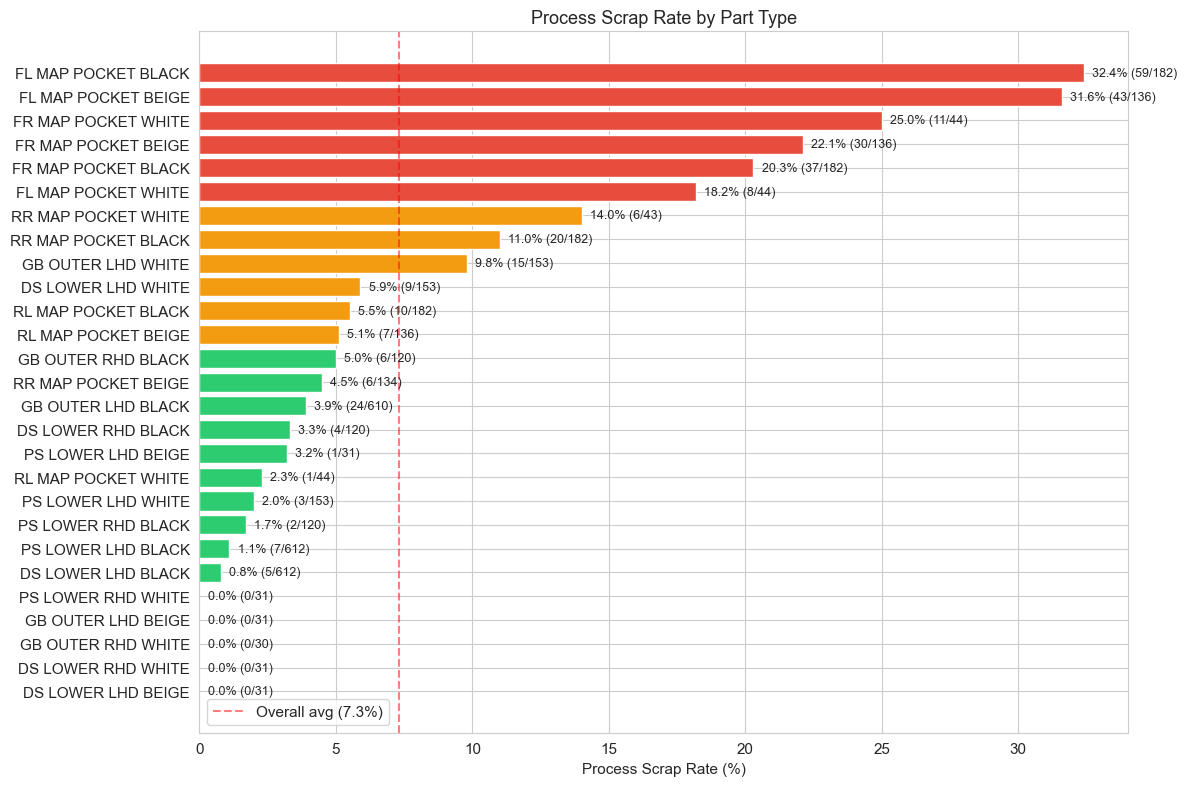


Highest scrap parts (>15%):
  FL MAP POCKET BLACK: 32.4% (59/182)
  FL MAP POCKET BEIGE: 31.6% (43/136)
  FR MAP POCKET WHITE: 25.0% (11/44)
  FR MAP POCKET BEIGE: 22.1% (30/136)
  FR MAP POCKET BLACK: 20.3% (37/182)
  FL MAP POCKET WHITE: 18.2% (8/44)


In [5]:
part_stats = df.groupby('part_desc').agg(
    total=('ID', 'count'),
    scrap=('defect_scope', lambda x: (x == 'Process Defect').sum())
).reset_index()
part_stats['rate'] = (part_stats['scrap'] / part_stats['total'] * 100).round(1)
part_stats = part_stats.sort_values('rate', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if r > 15 else '#f39c12' if r > 5 else '#2ecc71' for r in part_stats['rate']]
bars = ax.barh(part_stats['part_desc'], part_stats['rate'], color=colors)
for bar, row in zip(bars, part_stats.itertuples()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{row.rate}% ({row.scrap}/{row.total})', va='center', fontsize=9)

ax.set_xlabel('Process Scrap Rate (%)')
ax.set_title('Process Scrap Rate by Part Type')
ax.axvline(x=7.3, color='red', linestyle='--', alpha=0.5, label='Overall avg (7.3%)')
ax.legend()
plt.tight_layout()
plt.savefig('02_scrap_by_part.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nHighest scrap parts (>15%):")
high_scrap = part_stats[part_stats['rate'] > 15].sort_values('rate', ascending=False)
for _, row in high_scrap.iterrows():
    print(f"  {row['part_desc']}: {row['rate']}% ({row['scrap']}/{row['total']})")

### 3.2 Temporal Pattern — Scrap Over Time

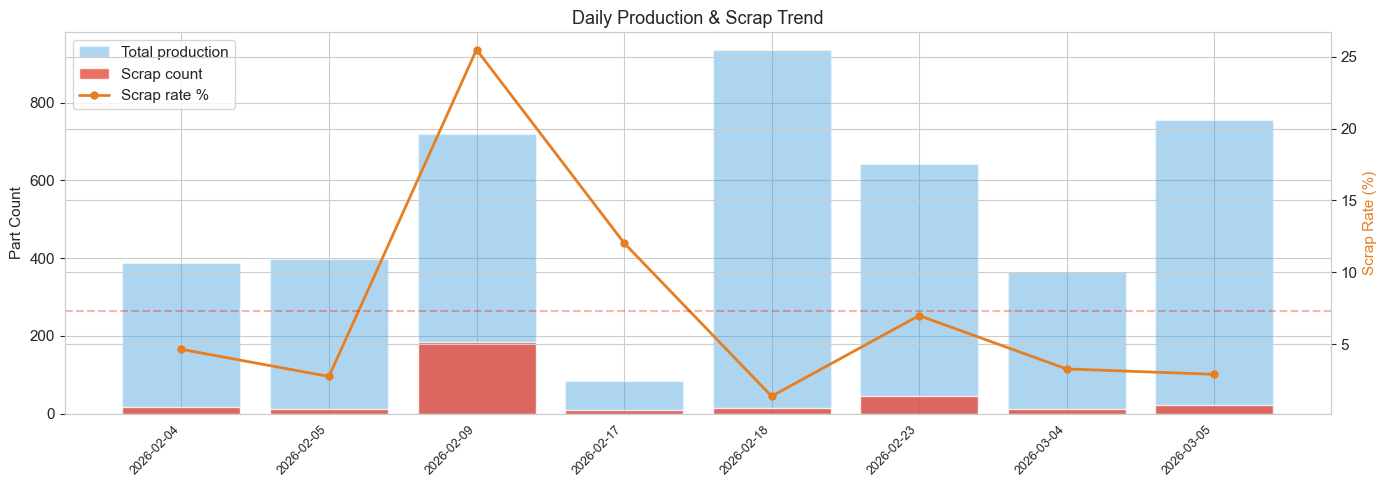

In [6]:
df['date'] = df['built_time'].dt.date

daily = df.groupby('date').agg(
    total=('ID', 'count'),
    scrap=('defect_scope', lambda x: (x == 'Process Defect').sum())
).reset_index()
daily['rate'] = daily['scrap'] / daily['total'] * 100

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(range(len(daily)), daily['total'], color='#3498db', alpha=0.4, label='Total production')
ax1.bar(range(len(daily)), daily['scrap'], color='#e74c3c', alpha=0.8, label='Scrap count')
ax1.set_ylabel('Part Count')
ax1.set_xticks(range(len(daily)))
ax1.set_xticklabels([str(d) for d in daily['date']], rotation=45, ha='right', fontsize=9)

ax2 = ax1.twinx()
ax2.plot(range(len(daily)), daily['rate'], 'o-', color='#e67e22', linewidth=2, markersize=5, label='Scrap rate %')
ax2.set_ylabel('Scrap Rate (%)', color='#e67e22')
ax2.axhline(y=7.3, color='red', linestyle='--', alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Daily Production & Scrap Trend')
plt.tight_layout()
plt.savefig('03_temporal_trend.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Section-wise Root Cause Analysis

For each process defect, we compare the parameter distributions of **scrapped parts vs good parts** using Welch's t-test (unequal variance). Only statistically significant deviations (p < 0.05) are reported.

In [7]:
good = df[df['description'] == 'Good']

def analyze_defect(defect_name, min_samples=5):
    """Compare scrap vs good for all parameters, return significant deviations."""
    bad = df[df['description'] == defect_name]
    if len(bad) < min_samples:
        return None
    
    results = []
    for section, info in SECTIONS.items():
        for param in info['params']:
            if param not in df.columns:
                continue
            g_vals = good[param].dropna()
            b_vals = bad[param].dropna()
            if len(g_vals) < 10 or len(b_vals) < 3:
                continue
            
            t_stat, p_val = stats.ttest_ind(g_vals, b_vals, equal_var=False)
            g_mean, g_std = g_vals.mean(), g_vals.std()
            b_mean = b_vals.mean()
            
            if p_val < 0.05 and g_mean != 0:
                pct_diff = ((b_mean - g_mean) / g_mean) * 100
                direction = 'HIGHER' if b_mean > g_mean else 'LOWER'
                results.append({
                    'Section': section,
                    'Parameter': param,
                    'Good Mean': round(g_mean, 1),
                    'Good Std': round(g_std, 1),
                    'Scrap Mean': round(b_mean, 1),
                    'Direction': direction,
                    'Deviation %': round(abs(pct_diff), 1),
                    'p-value': round(p_val, 4)
                })
    
    return pd.DataFrame(results).sort_values('Deviation %', ascending=False) if results else None

# Analyze each defect
defect_analyses = {}
for defect in PROCESS_DEFECTS:
    count = (df['description'] == defect).sum()
    if count >= 5:
        result = analyze_defect(defect)
        if result is not None:
            defect_analyses[defect] = result
            
print(f"Analyzed {len(defect_analyses)} defect types with sufficient data:")
for d, r in defect_analyses.items():
    n = (df['description'] == d).sum()
    print(f"  {d}: {n} samples, {len(r)} significant parameter deviations")

Analyzed 6 defect types with sufficient data:
  Low Glue/Read Thru/Impression: 130 samples, 39 significant parameter deviations
  Wrinkle: 51 samples, 38 significant parameter deviations
  Dent: 50 samples, 31 significant parameter deviations
  Bumps / lumps: 48 samples, 27 significant parameter deviations
  Out of dimension: 21 samples, 29 significant parameter deviations
  Burnt Carpet / Vynil: 11 samples, 26 significant parameter deviations


### 4.1 Low Glue / Read Through / Impression (n=130) — Largest Defect Category

In [8]:
defect = 'Low Glue/Read Thru/Impression'
analysis = defect_analyses[defect]

# Show top deviations by section
print(f"=== {defect} ({(df['description']==defect).sum()} parts) ===")
print(f"\nTop parameter deviations (Good vs Scrap):\n")
display_cols = ['Section', 'Parameter', 'Good Mean', 'Good Std', 'Scrap Mean', 'Direction', 'Deviation %']
# Show top 5 per section
for section in SECTIONS.keys():
    sec_data = analysis[analysis['Section'] == section].head(5)
    if len(sec_data) > 0:
        print(f"\n  [{section}]")
        for _, row in sec_data.iterrows():
            arrow = '▲' if row['Direction'] == 'HIGHER' else '▼'
            print(f"    {arrow} {row['Parameter']:<40} Good: {row['Good Mean']:>8} ± {row['Good Std']:<8} Scrap: {row['Scrap Mean']:>8}  ({row['Direction']} by {row['Deviation %']}%)")

=== Low Glue/Read Thru/Impression (130 parts) ===

Top parameter deviations (Good vs Scrap):


  [Roll Coating]
    ▼ Roller Gap RH                            Good:     14.9 ± 7.4      Scrap:      5.2  (LOWER by 64.9%)
    ▼ Roller Gap LH                            Good:     16.6 ± 6.9      Scrap:      7.2  (LOWER by 56.8%)
    ▼ Glue Temp                                Good:    152.5 ± 4.8      Scrap:    146.7  (LOWER by 3.8%)
    ▼ Pick Material Pos                        Good:    216.6 ± 4.8      Scrap:    210.5  (LOWER by 2.8%)

  [Grippers & Clamp Frame]
    ▼ Pos Vinyl S Length                       Good:    198.2 ± 108.5    Scrap:     43.1  (LOWER by 78.2%)
    ▼ Pos Vinyl S Width                        Good:     69.6 ± 106.6    Scrap:     22.8  (LOWER by 67.2%)
    ▼ Pos Vinyl N Width                        Good:    114.2 ± 135.6    Scrap:     54.6  (LOWER by 52.2%)
    ▲ Stretch Cross Form                       Good:   6353.4 ± 2268.2   Scrap:   9192.4  (HIGHER by 44.7%)
    ▲

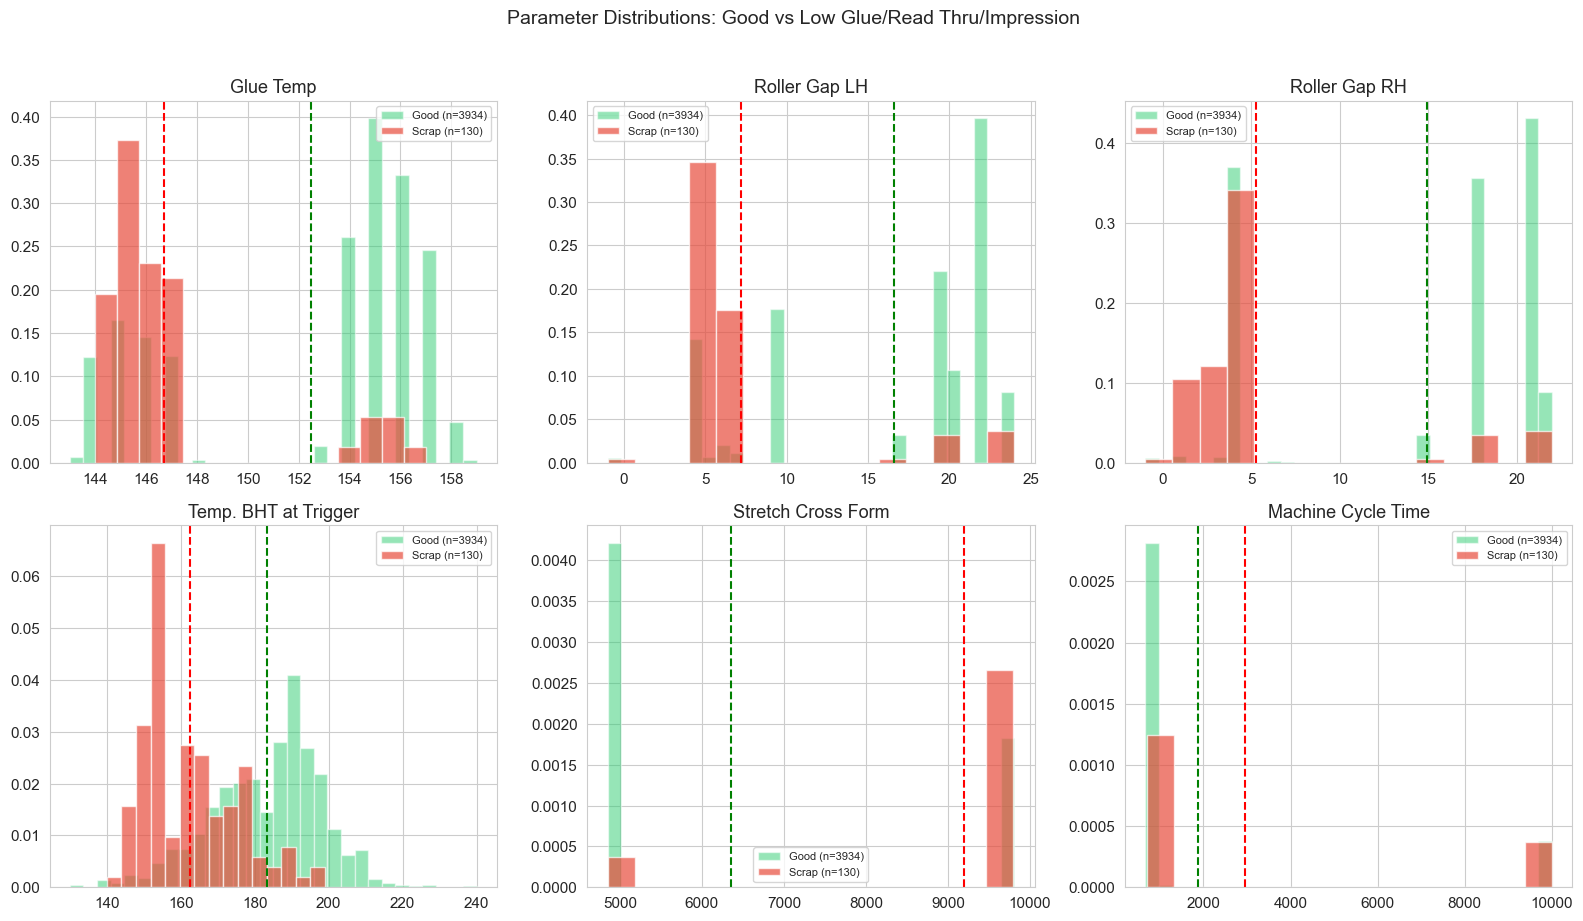

In [9]:
# Visualization: Key parameter distributions — Low Glue
key_params_glue = ['Glue Temp', 'Roller Gap LH', 'Roller Gap RH', 
                   'Temp. BHT at Trigger', 'Stretch Cross Form', 'Machine Cycle Time']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, param in zip(axes.flat, key_params_glue):
    g_vals = good[param].dropna()
    b_vals = df[df['description'] == defect][param].dropna()
    
    ax.hist(g_vals, bins=30, alpha=0.5, color='#2ecc71', label=f'Good (n={len(g_vals)})', density=True)
    ax.hist(b_vals, bins=15, alpha=0.7, color='#e74c3c', label=f'Scrap (n={len(b_vals)})', density=True)
    ax.axvline(g_vals.mean(), color='green', linestyle='--', linewidth=1.5)
    ax.axvline(b_vals.mean(), color='red', linestyle='--', linewidth=1.5)
    ax.set_title(param)
    ax.legend(fontsize=8)

fig.suptitle(f'Parameter Distributions: Good vs {defect}', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('04_low_glue_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Wrinkle (n=51)

In [10]:
defect = 'Wrinkle'
analysis = defect_analyses[defect]

print(f"=== {defect} ({(df['description']==defect).sum()} parts) ===")
print(f"\nTop parameter deviations:\n")
for section in SECTIONS.keys():
    sec_data = analysis[analysis['Section'] == section].head(5)
    if len(sec_data) > 0:
        print(f"\n  [{section}]")
        for _, row in sec_data.iterrows():
            arrow = '▲' if row['Direction'] == 'HIGHER' else '▼'
            print(f"    {arrow} {row['Parameter']:<40} Good: {row['Good Mean']:>8} ± {row['Good Std']:<8} Scrap: {row['Scrap Mean']:>8}  ({row['Direction']} by {row['Deviation %']}%)")

=== Wrinkle (51 parts) ===

Top parameter deviations:


  [Roll Coating]
    ▼ Roller Gap LH                            Good:     16.6 ± 6.9      Scrap:      6.1  (LOWER by 63.5%)
    ▼ Roller Gap RH                            Good:     14.9 ± 7.4      Scrap:      5.7  (LOWER by 62.0%)
    ▼ Glue Temp                                Good:    152.5 ± 4.8      Scrap:    146.6  (LOWER by 3.8%)
    ▼ Pick Material Pos                        Good:    216.6 ± 4.8      Scrap:    211.6  (LOWER by 2.3%)

  [Grippers & Clamp Frame]
    ▲ Pos Vinyl S Width                        Good:     69.6 ± 106.6    Scrap:    227.9  (HIGHER by 227.6%)
    ▼ Pos Vinyl N Width                        Good:    114.2 ± 135.6    Scrap:     36.1  (LOWER by 68.4%)
    ▼ Pos Vinyl N Length                       Good:     82.2 ± 90.1     Scrap:     35.4  (LOWER by 57.0%)
    ▲ Stretch Cross Form                       Good:   6353.4 ± 2268.2   Scrap:   9315.0  (HIGHER by 46.6%)
    ▲ Stretch Cross Stretch 3             

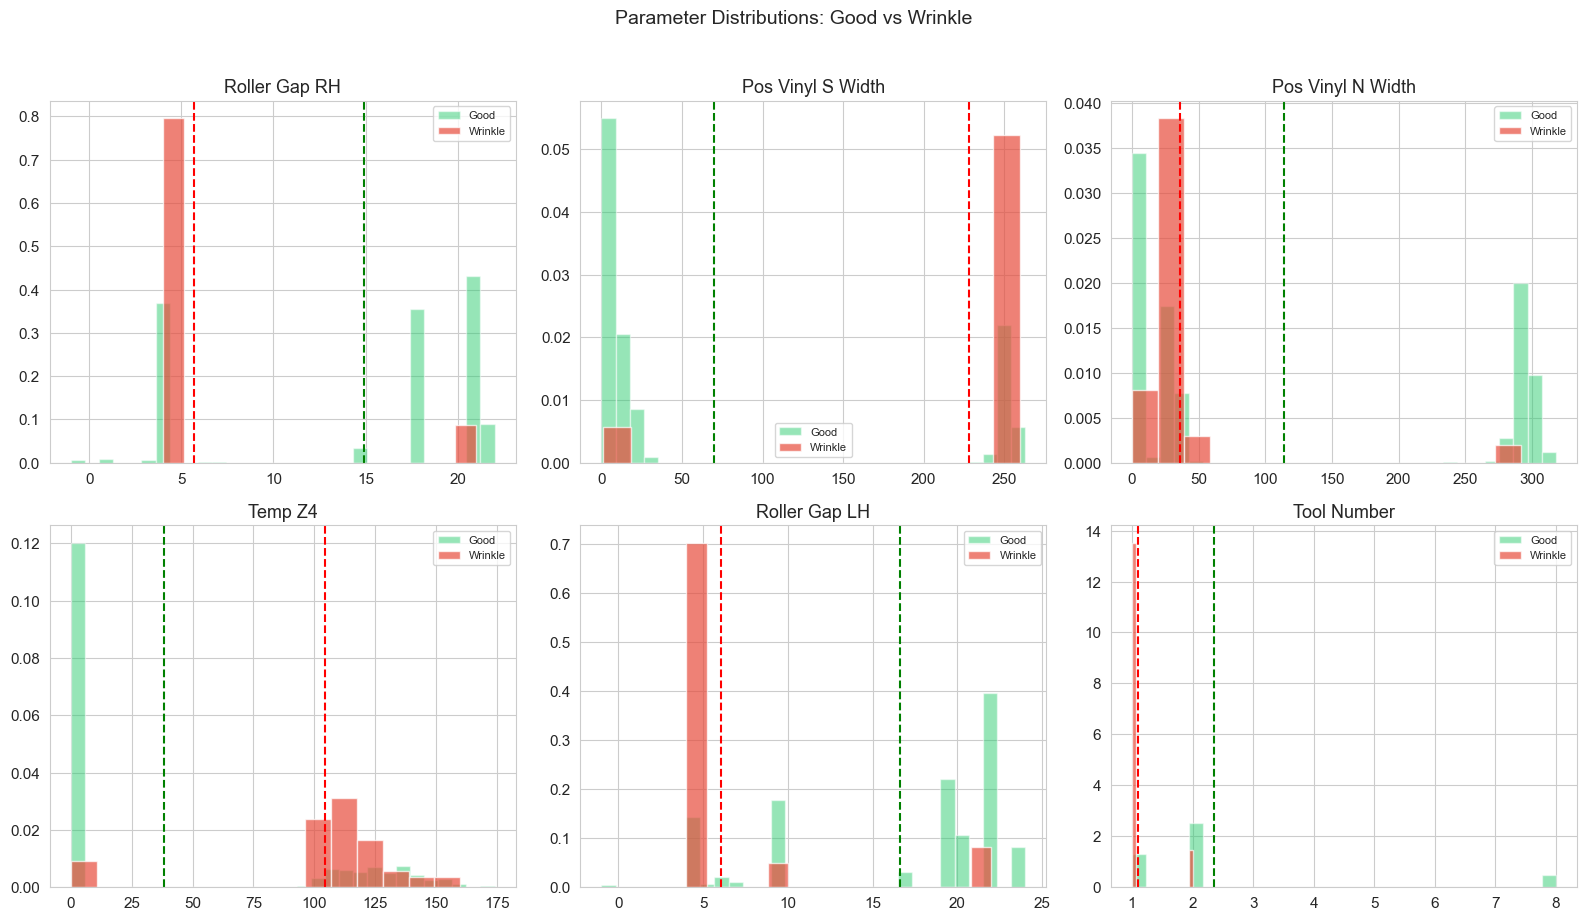

In [27]:
key_params_wrinkle = ['Roller Gap RH', 'Pos Vinyl S Width', 'Pos Vinyl N Width',
                      'Temp Z4', 'Roller Gap LH', 'Tool Number']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, param in zip(axes.flat, key_params_wrinkle):
    g_vals = good[param].dropna()
    b_vals = df[df['description'] == 'Wrinkle'][param].dropna()
    ax.hist(g_vals, bins=30, alpha=0.5, color='#2ecc71', label=f'Good', density=True)
    ax.hist(b_vals, bins=15, alpha=0.7, color='#e74c3c', label=f'Wrinkle', density=True)
    ax.axvline(g_vals.mean(), color='green', linestyle='--', linewidth=1.5)
    ax.axvline(b_vals.mean(), color='red', linestyle='--', linewidth=1.5)
    ax.set_title(param)
    ax.legend(fontsize=8)

fig.suptitle('Parameter Distributions: Good vs Wrinkle', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('05_wrinkle_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Dent (n=50)

In [12]:
defect = 'Dent'
analysis = defect_analyses[defect]

print(f"=== {defect} ({(df['description']==defect).sum()} parts) ===")
print(f"\nTop parameter deviations:\n")
for section in SECTIONS.keys():
    sec_data = analysis[analysis['Section'] == section].head(5)
    if len(sec_data) > 0:
        print(f"\n  [{section}]")
        for _, row in sec_data.iterrows():
            arrow = '▲' if row['Direction'] == 'HIGHER' else '▼'
            print(f"    {arrow} {row['Parameter']:<40} Good: {row['Good Mean']:>8} ± {row['Good Std']:<8} Scrap: {row['Scrap Mean']:>8}  ({row['Direction']} by {row['Deviation %']}%)")

=== Dent (50 parts) ===

Top parameter deviations:


  [Roll Coating]
    ▼ Roller Gap RH                            Good:     14.9 ± 7.4      Scrap:      8.0  (LOWER by 46.1%)
    ▼ Roller Gap LH                            Good:     16.6 ± 6.9      Scrap:     11.8  (LOWER by 28.7%)
    ▼ Glue Temp                                Good:    152.5 ± 4.8      Scrap:    148.0  (LOWER by 2.9%)
    ▲ Pick Material Pos                        Good:    216.6 ± 4.8      Scrap:    218.0  (HIGHER by 0.7%)

  [Grippers & Clamp Frame]
    ▲ Pos Vinyl S Width                        Good:     69.6 ± 106.6    Scrap:    191.1  (HIGHER by 174.7%)
    ▲ Stretch Cross Form                       Good:   6353.4 ± 2268.2   Scrap:   8608.6  (HIGHER by 35.5%)
    ▲ Stretch Cross Stretch 3                  Good:   6316.6 ± 2193.6   Scrap:   8498.2  (HIGHER by 34.5%)
    ▲ Stretch Cross Stretch 2                  Good:   6257.1 ± 2168.8   Scrap:   8416.6  (HIGHER by 34.5%)
    ▲ Stretch Cross Stretch 1             

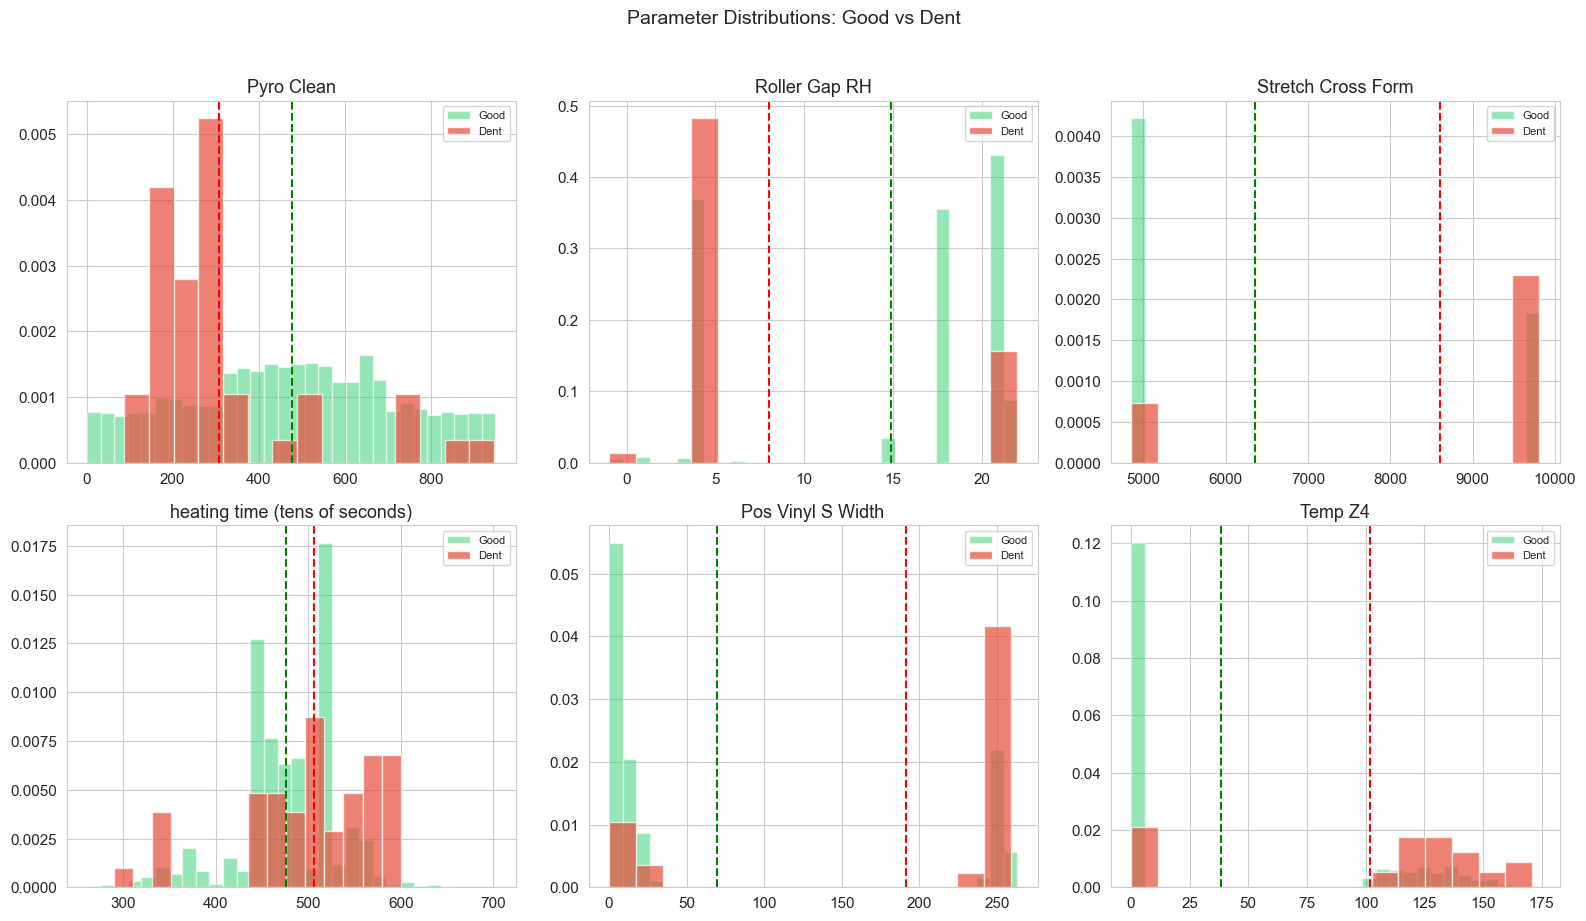

In [13]:
key_params_dent = ['Pyro Clean', 'Roller Gap RH', 'Stretch Cross Form',
                   'heating time (tens of seconds)', 'Pos Vinyl S Width', 'Temp Z4']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, param in zip(axes.flat, key_params_dent):
    g_vals = good[param].dropna()
    b_vals = df[df['description'] == 'Dent'][param].dropna()
    ax.hist(g_vals, bins=30, alpha=0.5, color='#2ecc71', label=f'Good', density=True)
    ax.hist(b_vals, bins=15, alpha=0.7, color='#e74c3c', label=f'Dent', density=True)
    ax.axvline(g_vals.mean(), color='green', linestyle='--', linewidth=1.5)
    ax.axvline(b_vals.mean(), color='red', linestyle='--', linewidth=1.5)
    ax.set_title(param)
    ax.legend(fontsize=8)

fig.suptitle('Parameter Distributions: Good vs Dent', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('06_dent_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Bumps / Lumps (n=48)

In [14]:
defect = 'Bumps / lumps'
analysis = defect_analyses[defect]

print(f"=== {defect} ({(df['description']==defect).sum()} parts) ===")
print(f"\nTop parameter deviations:\n")
for section in SECTIONS.keys():
    sec_data = analysis[analysis['Section'] == section].head(5)
    if len(sec_data) > 0:
        print(f"\n  [{section}]")
        for _, row in sec_data.iterrows():
            arrow = '▲' if row['Direction'] == 'HIGHER' else '▼'
            print(f"    {arrow} {row['Parameter']:<40} Good: {row['Good Mean']:>8} ± {row['Good Std']:<8} Scrap: {row['Scrap Mean']:>8}  ({row['Direction']} by {row['Deviation %']}%)")

=== Bumps / lumps (48 parts) ===

Top parameter deviations:


  [Roll Coating]
    ▼ Roller Gap RH                            Good:     14.9 ± 7.4      Scrap:     11.5  (LOWER by 22.9%)
    ▼ Roller Gap LH                            Good:     16.6 ± 6.9      Scrap:     13.3  (LOWER by 19.9%)
    ▼ Glue Temp                                Good:    152.5 ± 4.8      Scrap:    150.5  (LOWER by 1.3%)

  [Grippers & Clamp Frame]
    ▲ Pos Vinyl S Width                        Good:     69.6 ± 106.6    Scrap:    114.6  (HIGHER by 64.7%)
    ▲ Stretch Cross Form                       Good:   6353.4 ± 2268.2   Scrap:   7232.9  (HIGHER by 13.8%)
    ▲ Stretch Cross Stretch 2                  Good:   6257.1 ± 2168.8   Scrap:   7089.0  (HIGHER by 13.3%)
    ▲ Stretch Cross Stretch 3                  Good:   6316.6 ± 2193.6   Scrap:   7154.0  (HIGHER by 13.3%)
    ▲ Stretch Cross Pick Up                    Good:   6233.8 ± 2147.9   Scrap:   7054.6  (HIGHER by 13.2%)

  [Oven]
    ▲ Temp Z4          

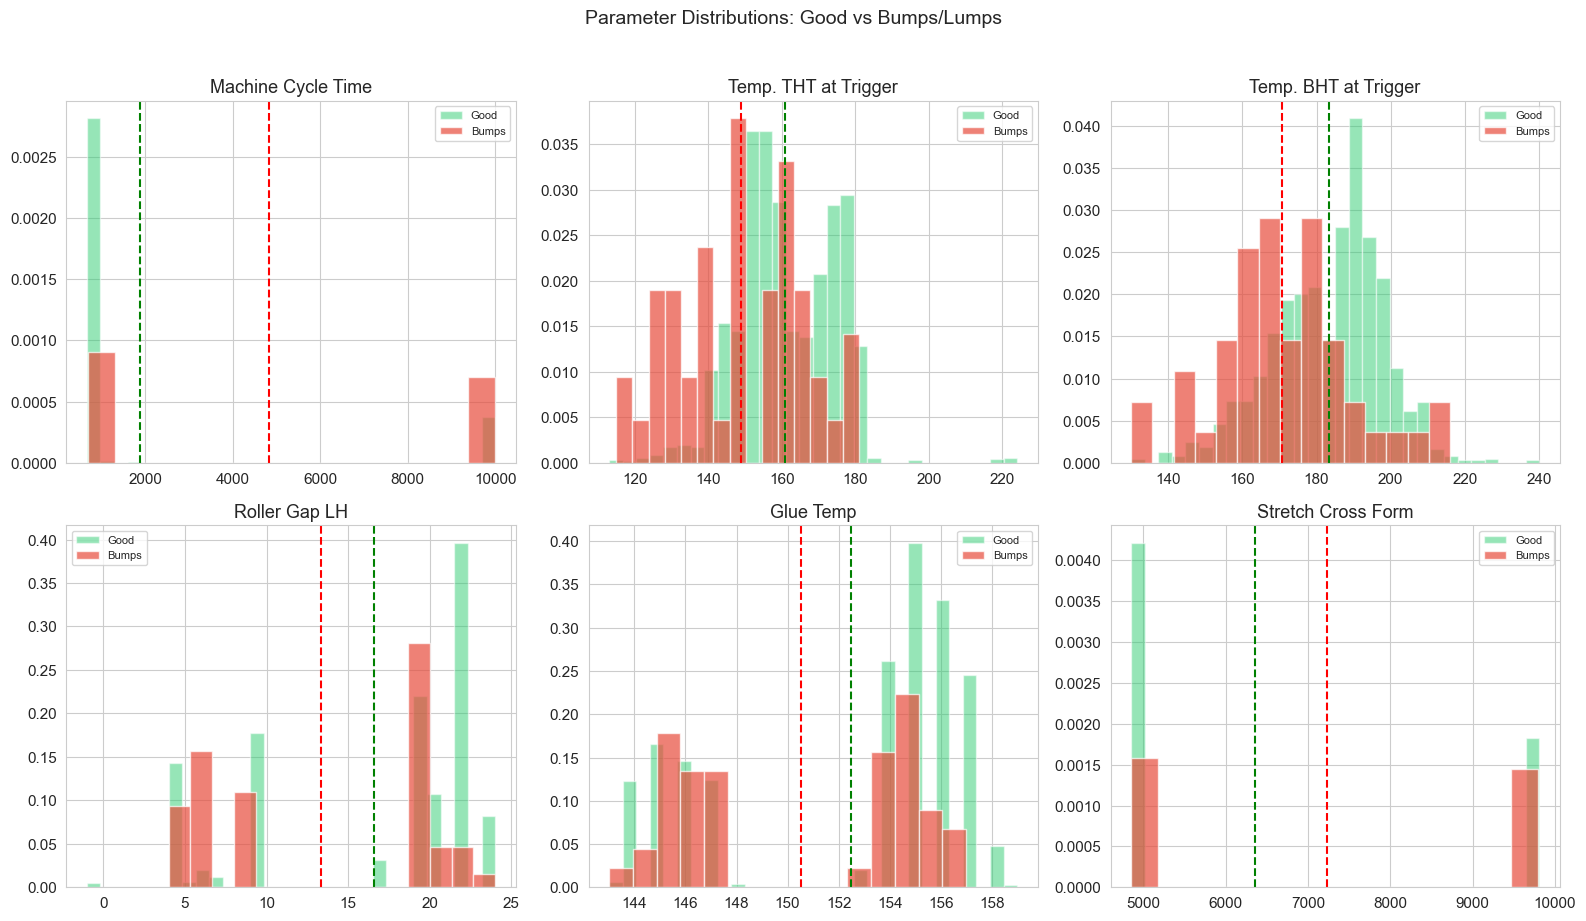

In [15]:
key_params_bumps = ['Machine Cycle Time', 'Temp. THT at Trigger', 'Temp. BHT at Trigger',
                    'Roller Gap LH', 'Glue Temp', 'Stretch Cross Form']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, param in zip(axes.flat, key_params_bumps):
    g_vals = good[param].dropna()
    b_vals = df[df['description'] == 'Bumps / lumps'][param].dropna()
    ax.hist(g_vals, bins=30, alpha=0.5, color='#2ecc71', label=f'Good', density=True)
    ax.hist(b_vals, bins=15, alpha=0.7, color='#e74c3c', label=f'Bumps', density=True)
    ax.axvline(g_vals.mean(), color='green', linestyle='--', linewidth=1.5)
    ax.axvline(b_vals.mean(), color='red', linestyle='--', linewidth=1.5)
    ax.set_title(param)
    ax.legend(fontsize=8)

fig.suptitle('Parameter Distributions: Good vs Bumps/Lumps', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('07_bumps_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Out of Dimension (n=21) & Burnt Carpet (n=11)

In [16]:
for defect in ['Out of dimension', 'Burnt Carpet / Vynil']:
    if defect in defect_analyses:
        analysis = defect_analyses[defect]
        print(f"\n{'='*80}")
        print(f"{defect} ({(df['description']==defect).sum()} parts)")
        print(f"{'='*80}")
        for section in SECTIONS.keys():
            sec_data = analysis[analysis['Section'] == section].head(4)
            if len(sec_data) > 0:
                print(f"\n  [{section}]")
                for _, row in sec_data.iterrows():
                    arrow = '▲' if row['Direction'] == 'HIGHER' else '▼'
                    print(f"    {arrow} {row['Parameter']:<40} Good: {row['Good Mean']:>8}  Scrap: {row['Scrap Mean']:>8}  ({row['Direction']} by {row['Deviation %']}%)")


Out of dimension (21 parts)

  [Roll Coating]
    ▼ Roller Gap LH                            Good:     16.6  Scrap:      7.7  (LOWER by 53.9%)
    ▼ Roller Gap RH                            Good:     14.9  Scrap:      7.3  (LOWER by 50.8%)
    ▼ Glue Temp                                Good:    152.5  Scrap:    148.0  (LOWER by 2.9%)
    ▼ Pick Material Pos                        Good:    216.6  Scrap:    211.0  (LOWER by 2.6%)

  [Grippers & Clamp Frame]
    ▲ Pos Vinyl S Width                        Good:     69.6  Scrap:    195.4  (HIGHER by 180.8%)
    ▲ Stretch Cross Form                       Good:   6353.4  Scrap:   8624.3  (HIGHER by 35.7%)
    ▲ Stretch Cross Stretch 2                  Good:   6257.1  Scrap:   8425.2  (HIGHER by 34.7%)
    ▲ Stretch Cross Stretch 3                  Good:   6316.6  Scrap:   8511.4  (HIGHER by 34.7%)

  [Oven]
    ▲ Temp Z4                                  Good:     38.3  Scrap:     99.0  (HIGHER by 158.9%)
    ▼ Capacity BHT                   

---
## 5. Operating Windows — Safe vs Risky Ranges

For key parameters, we compute the **"safe operating window"** (range where >95% of good parts fall) versus the typical range of scrapped parts.

In [17]:
# Compute operating windows for key parameters
key_process_params = [
    'Glue Temp', 'Roller Gap LH', 'Roller Gap RH',
    'Temp. THT at Trigger', 'Temp. BHT at Trigger',
    'Temp Z1', 'Temp Z2', 'Temp Z3',
    'heating time (tens of seconds)',
    'Machine Cycle Time',
    'Stretch Cross Form', 'Stetch Length Form',
    'Vacuum Time Tool Cavity A', 'Vacuum Time Tool Cavity B',
    'Pyro Clean'
]

process_scrap_df = df[df['defect_scope'] == 'Process Defect']

print(f"{'Parameter':<35} {'Good P5':>8} {'Good P50':>9} {'Good P95':>9} {'Scrap P5':>9} {'Scrap P50':>10} {'Scrap P95':>10}   Status")
print('─' * 110)

operating_windows = []
for param in key_process_params:
    if param not in df.columns:
        continue
    g = good[param].dropna()
    b = process_scrap_df[param].dropna()
    if len(g) < 10 or len(b) < 5:
        continue
    
    g_p5, g_p50, g_p95 = np.percentile(g, [5, 50, 95])
    b_p5, b_p50, b_p95 = np.percentile(b, [5, 50, 95])
    
    # Check if scrap median falls outside good P5-P95 range
    if b_p50 < g_p5 or b_p50 > g_p95:
        status = '!! CRITICAL'
    elif abs(b_p50 - g_p50) / (g_p95 - g_p5 + 1e-6) > 0.3:
        status = '!  WARNING'
    else:
        status = '   OK'
    
    operating_windows.append({
        'Parameter': param, 
        'Safe Low (P5)': round(g_p5, 1), 
        'Safe Target (P50)': round(g_p50, 1),
        'Safe High (P95)': round(g_p95, 1),
        'Status': status
    })
    
    print(f"{param:<35} {g_p5:>8.1f} {g_p50:>9.1f} {g_p95:>9.1f} {b_p5:>9.1f} {b_p50:>10.1f} {b_p95:>10.1f}   {status}")

windows_df = pd.DataFrame(operating_windows)
print(f"\nCritical/Warning parameters: {len(windows_df[windows_df['Status'].str.contains('CRITICAL|WARNING')])}")

Parameter                            Good P5  Good P50  Good P95  Scrap P5  Scrap P50  Scrap P95   Status
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
Glue Temp                              144.0     155.0     157.0     144.0      146.0      156.0   !  WARNING
Roller Gap LH                            4.0      19.0      24.0       4.0        7.0       22.0   !  WARNING
Roller Gap RH                            4.0      18.0      22.0       1.0        4.0       21.0   !  WARNING
Temp. THT at Trigger                   140.0     160.0     180.0     139.3      155.0      181.3      OK
Temp. BHT at Trigger                   157.7     186.0     205.0     149.7      171.0      200.3   !  WARNING
Temp Z1                                116.0     144.0     174.0     110.0      134.5      173.3      OK
Temp Z2                                111.7     139.0     169.0     107.0      130.0      166.0      OK
Temp Z3                     

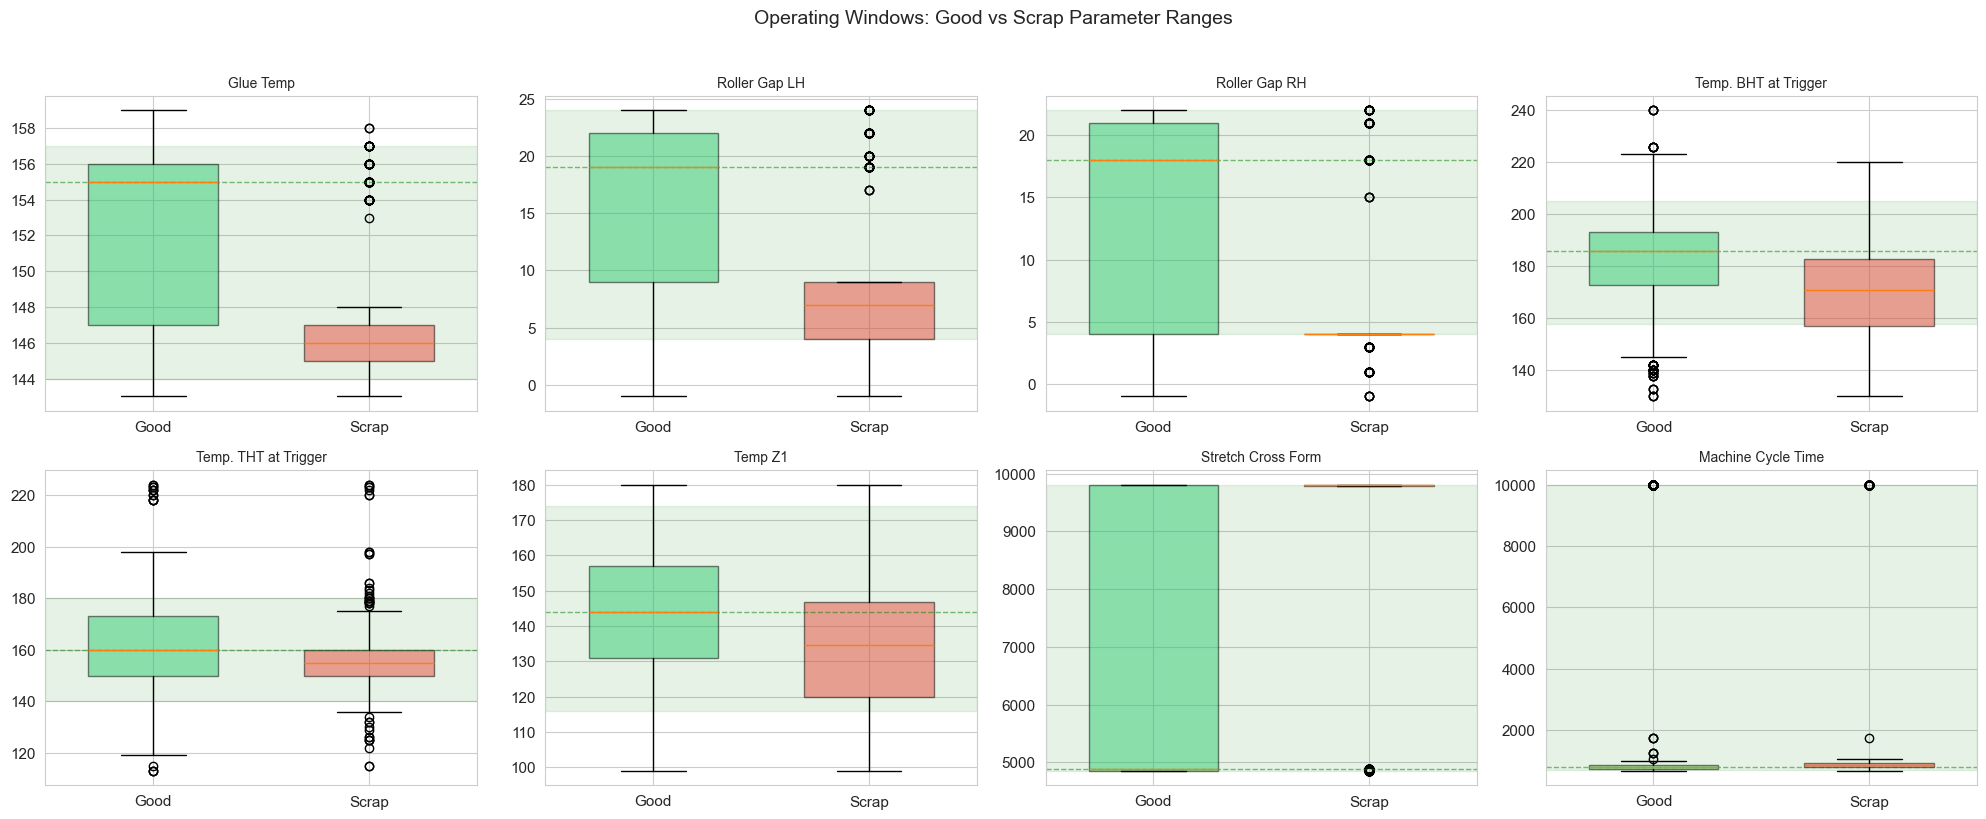

In [18]:
# Visual: Operating windows for critical parameters
critical_params = ['Glue Temp', 'Roller Gap LH', 'Roller Gap RH', 
                   'Temp. BHT at Trigger', 'Temp. THT at Trigger',
                   'Temp Z1', 'Stretch Cross Form', 'Machine Cycle Time']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, param in zip(axes.flat, critical_params):
    if param not in df.columns:
        continue
    g = good[param].dropna()
    b = process_scrap_df[param].dropna()
    
    g_p5, g_p50, g_p95 = np.percentile(g, [5, 50, 95])
    
    # Box plots
    bp = ax.boxplot([g.values, b.values], labels=['Good', 'Scrap'], 
                    patch_artist=True, widths=0.6)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][0].set_alpha(0.5)
    bp['boxes'][1].set_facecolor('#e74c3c')
    bp['boxes'][1].set_alpha(0.5)
    
    # Safe zone shading
    ax.axhspan(g_p5, g_p95, alpha=0.1, color='green', label='Safe zone (P5-P95)')
    ax.axhline(g_p50, color='green', linestyle='--', alpha=0.5, linewidth=1)
    
    ax.set_title(param, fontsize=10)

fig.suptitle('Operating Windows: Good vs Scrap Parameter Ranges', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('08_operating_windows.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Correlation: Which Parameters Move Together?

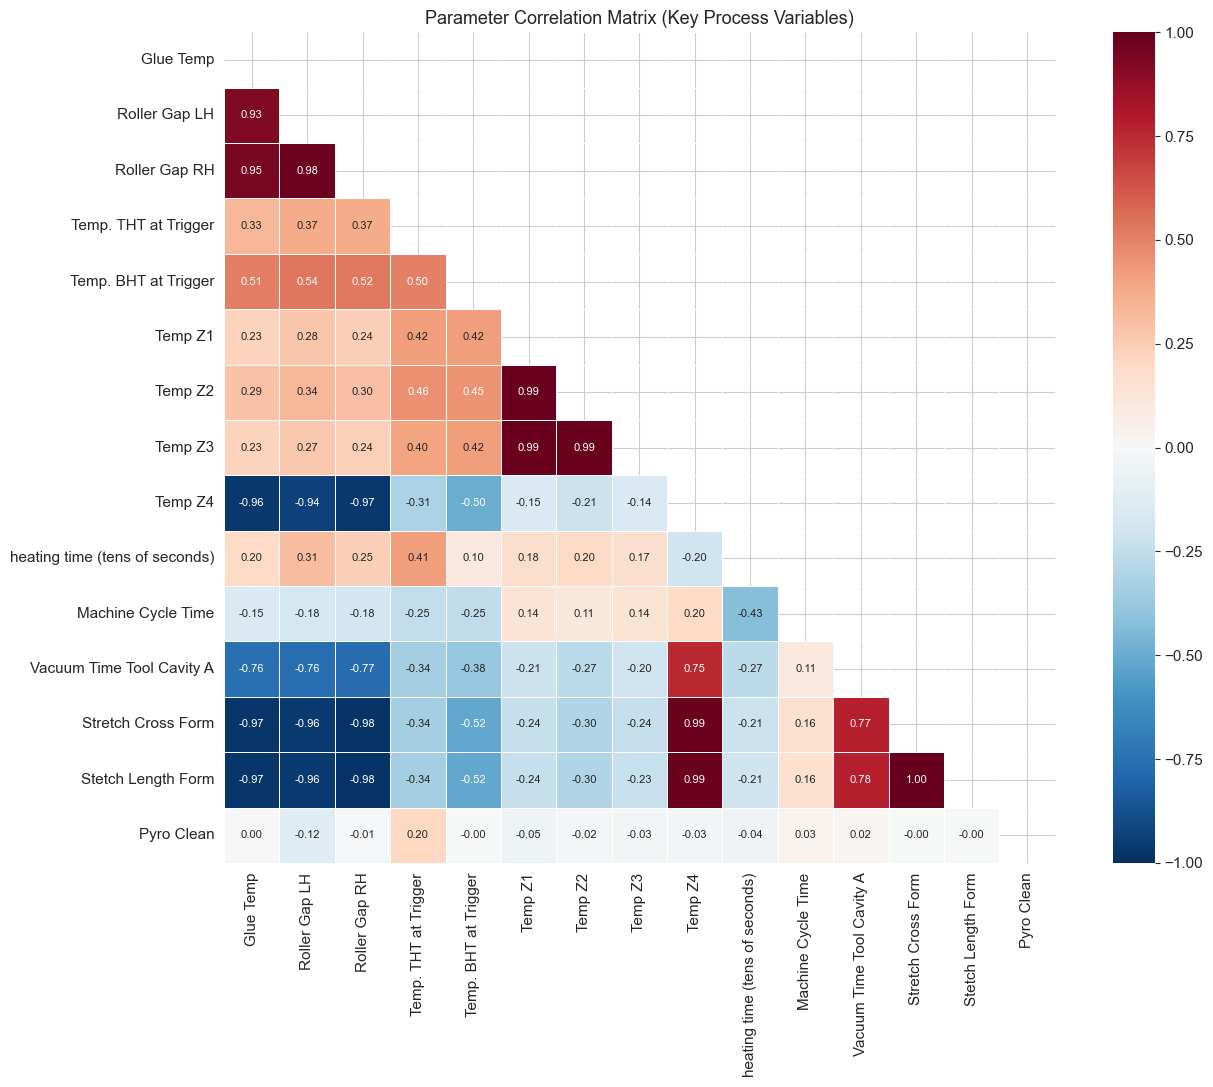

In [19]:
# Correlation heatmap of key parameters
corr_params = [
    'Glue Temp', 'Roller Gap LH', 'Roller Gap RH',
    'Temp. THT at Trigger', 'Temp. BHT at Trigger',
    'Temp Z1', 'Temp Z2', 'Temp Z3', 'Temp Z4',
    'heating time (tens of seconds)',
    'Machine Cycle Time',
    'Vacuum Time Tool Cavity A',
    'Stretch Cross Form', 'Stetch Length Form',
    'Pyro Clean'
]
corr_params = [p for p in corr_params if p in df.columns]

corr_matrix = df[corr_params].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'fontsize': 8})
ax.set_title('Parameter Correlation Matrix (Key Process Variables)', fontsize=13)
plt.tight_layout()
plt.savefig('09_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Defect-wise Recommendation Engine

Based on the statistical analysis above, here are the **actionable recommendations** for each defect type. When a scrap event is detected, these recommendations tell the operator **what to check and adjust**.

In [20]:
# Build recommendation engine
recommendations = {
    'Low Glue/Read Thru/Impression': {
        'root_causes': [
            'Bottom Heater Temperature (BHT) too low → vinyl not softened enough for glue adhesion',
            'Roller Gap too narrow → insufficient glue application',
            'Glue Temperature below optimal → poor adhesive spread',
            'Excessive cross-stretching → thins the glue layer'
        ],
        'actions': [
            ('INCREASE', 'Temp. BHT at Trigger', 'from ~162 to ≥180', 'CRITICAL'),
            ('WIDEN', 'Roller Gap LH', 'from ~7 to ≥15', 'CRITICAL'),
            ('WIDEN', 'Roller Gap RH', 'from ~5 to ≥13', 'CRITICAL'),
            ('INCREASE', 'Glue Temp', 'from ~147 to ≥150', 'HIGH'),
            ('REDUCE', 'Stretch Cross Form', 'from ~9192 to ≤7000', 'HIGH'),
            ('REDUCE', 'Machine Cycle Time', 'from ~2954 to ≤2000', 'MEDIUM'),
            ('INCREASE', 'Zone Temps (Z1-Z3)', 'from ~128-133 to ≥138', 'MEDIUM')
        ]
    },
    'Wrinkle': {
        'root_causes': [
            'Top Heater Temperature (THT) too low → vinyl not pliable enough for smooth forming',
            'Zone temperatures (Z1-Z3) too low → uneven heating creates stress points',
            'Excessive cross-stretching → material over-stretched in width direction',
            'Insufficient heating time → vinyl not uniformly softened'
        ],
        'actions': [
            ('INCREASE', 'Temp. THT at Trigger', 'from ~150 to ≥158', 'CRITICAL'),
            ('INCREASE', 'Temp Z1', 'from ~124 to ≥140', 'CRITICAL'),
            ('INCREASE', 'Temp Z2', 'from ~121 to ≥136', 'CRITICAL'),
            ('INCREASE', 'Temp Z3', 'from ~121 to ≥135', 'CRITICAL'),
            ('REDUCE', 'Stretch Cross Form', 'from ~9315 to ≤7000', 'HIGH'),
            ('INCREASE', 'heating time', 'from ~445 to ≥470 (tens of sec)', 'HIGH'),
            ('WIDEN', 'Roller Gap LH/RH', 'from ~6 to ≥15', 'MEDIUM')
        ]
    },
    'Dent': {
        'root_causes': [
            'Contaminants on tool surface → Pyro Clean value significantly lower for scrap',
            'Excessive cross-stretching → material too thin at contact points',
            'Extended heating time → vinyl too soft, picks up surface imperfections',
            'Roller gap too narrow → uneven pressure marks'
        ],
        'actions': [
            ('CLEAN', 'Forming Tool', 'Pyro Clean shows -36% deviation; clean tool before run', 'CRITICAL'),
            ('WIDEN', 'Roller Gap RH', 'from ~8 to ≥13', 'HIGH'),
            ('WIDEN', 'Roller Gap LH', 'from ~12 to ≥15', 'HIGH'),
            ('REDUCE', 'Stretch Cross Form', 'from ~8609 to ≤7000', 'HIGH'),
            ('CHECK', 'heating time', 'slightly high at 506 vs 476 nominal — reduce if possible', 'MEDIUM')
        ]
    },
    'Bumps / lumps': {
        'root_causes': [
            'Machine Cycle Time dramatically high (+158%) → indicates process interruption or delay',
            'THT and BHT temperatures both low → glue not properly activated',
            'Heating time insufficient → uneven vinyl softening',
            'Roller gap slightly narrow → glue application inconsistency'
        ],
        'actions': [
            ('REDUCE', 'Machine Cycle Time', 'from ~4820 to ≤2000 — investigate cause of long cycles', 'CRITICAL'),
            ('INCREASE', 'Temp. THT at Trigger', 'from ~149 to ≥158', 'HIGH'),
            ('INCREASE', 'Temp. BHT at Trigger', 'from ~171 to ≥180', 'HIGH'),
            ('INCREASE', 'heating time', 'from ~450 to ≥470 (tens of sec)', 'MEDIUM'),
            ('WIDEN', 'Roller Gap LH/RH', 'from ~12 to ≥15', 'MEDIUM'),
            ('INCREASE', 'Glue Temp', 'from ~151 to ≥152', 'LOW')
        ]
    },
    'Out of dimension': {
        'root_causes': [
            'BHT temperature too low → vinyl not sufficiently softened for accurate forming',
            'Bottom Heater Capacity reduced → insufficient heat delivery',
            'Excessive cross-stretching → dimensional distortion',
            'Roller gap too narrow → uneven material distribution'
        ],
        'actions': [
            ('INCREASE', 'Temp. BHT at Trigger', 'from ~172 to ≥180', 'CRITICAL'),
            ('INCREASE', 'Capacity BHT', 'from ~46 to ≥53', 'HIGH'),
            ('REDUCE', 'Stretch Cross Form', 'from ~8624 to ≤7000', 'HIGH'),
            ('WIDEN', 'Roller Gap LH', 'from ~8 to ≥15', 'HIGH'),
            ('WIDEN', 'Roller Gap RH', 'from ~7 to ≥13', 'HIGH')
        ]
    },
    'Burnt Carpet / Vynil': {
        'root_causes': [
            'Occurs predominantly on Tool #4-5 (higher tool numbers)',
            'Cross-stretch too LOW → material bunches and overheats locally',
            'Stretch length too low → insufficient material distribution',
            'Graining vacuum too HIGH → excessive forming pressure on hot vinyl'
        ],
        'actions': [
            ('INCREASE', 'Stretch Cross (all stages)', 'from ~4820-4864 to ≥5500', 'CRITICAL'),
            ('INCREASE', 'Stetch Length (all stages)', 'from 15400 to ≥15800', 'HIGH'),
            ('REDUCE', 'Graining Vacuum TTF Cavity 1/2', 'from ~87-88 to ≤75', 'HIGH'),
            ('NARROW', 'Roller Gap LH/RH', 'currently too wide at 21/19 — reduce to ~17', 'MEDIUM')
        ]
    }
}

# Display recommendations
priority_colors = {'CRITICAL': '\033[91m', 'HIGH': '\033[93m', 'MEDIUM': '\033[94m', 'LOW': '\033[90m'}

for defect, rec in recommendations.items():
    count = (df['description'] == defect).sum()
    print(f"\n{'='*90}")
    print(f"DEFECT: {defect} ({count} occurrences, {count/len(df)*100:.1f}% of production)")
    print(f"{'='*90}")
    
    print("\n  ROOT CAUSES:")
    for i, cause in enumerate(rec['root_causes'], 1):
        print(f"    {i}. {cause}")
    
    print("\n  RECOMMENDED ACTIONS:")
    for action, param, detail, priority in rec['actions']:
        print(f"    [{priority:<8}] {action} {param}: {detail}")


DEFECT: Low Glue/Read Thru/Impression (130 occurrences, 3.0% of production)

  ROOT CAUSES:
    1. Bottom Heater Temperature (BHT) too low → vinyl not softened enough for glue adhesion
    2. Roller Gap too narrow → insufficient glue application
    3. Glue Temperature below optimal → poor adhesive spread
    4. Excessive cross-stretching → thins the glue layer

  RECOMMENDED ACTIONS:
    [CRITICAL] INCREASE Temp. BHT at Trigger: from ~162 to ≥180
    [CRITICAL] WIDEN Roller Gap LH: from ~7 to ≥15
    [CRITICAL] WIDEN Roller Gap RH: from ~5 to ≥13
    [HIGH    ] INCREASE Glue Temp: from ~147 to ≥150
    [HIGH    ] REDUCE Stretch Cross Form: from ~9192 to ≤7000
    [MEDIUM  ] REDUCE Machine Cycle Time: from ~2954 to ≤2000
    [MEDIUM  ] INCREASE Zone Temps (Z1-Z3): from ~128-133 to ≥138

DEFECT: Wrinkle (51 occurrences, 1.2% of production)

  ROOT CAUSES:
    1. Top Heater Temperature (THT) too low → vinyl not pliable enough for smooth forming
    2. Zone temperatures (Z1-Z3) too low →

---
## 8. Live Recommendation Generator

This function takes a detected defect type and the current machine parameters, compares them against the "good" operating windows, and generates specific recommendations.

In [21]:
# Precompute good operating windows per parameter
good_windows = {}
for param in all_params:
    if param in good.columns:
        vals = good[param].dropna()
        if len(vals) > 20:
            good_windows[param] = {
                'p5': np.percentile(vals, 5),
                'p25': np.percentile(vals, 25),
                'median': np.percentile(vals, 50),
                'p75': np.percentile(vals, 75),
                'p95': np.percentile(vals, 95),
                'mean': vals.mean(),
                'std': vals.std()
            }

# Mapping of defect → most relevant parameters to check (ordered by importance)
DEFECT_PARAM_PRIORITY = {
    'Low Glue/Read Thru/Impression': [
        'Temp. BHT at Trigger', 'Roller Gap LH', 'Roller Gap RH', 'Glue Temp',
        'Stretch Cross Form', 'Machine Cycle Time', 'Temp Z1', 'Temp Z2', 'Temp Z3'
    ],
    'Wrinkle': [
        'Temp. THT at Trigger', 'Temp Z1', 'Temp Z2', 'Temp Z3',
        'Stretch Cross Form', 'heating time (tens of seconds)', 'Roller Gap LH', 'Roller Gap RH'
    ],
    'Dent': [
        'Pyro Clean', 'Roller Gap LH', 'Roller Gap RH', 'Stretch Cross Form',
        'heating time (tens of seconds)', 'Pos Vinyl S Width'
    ],
    'Bumps / lumps': [
        'Machine Cycle Time', 'Temp. THT at Trigger', 'Temp. BHT at Trigger',
        'heating time (tens of seconds)', 'Roller Gap LH', 'Roller Gap RH', 'Glue Temp'
    ],
    'Out of dimension': [
        'Temp. BHT at Trigger', 'Capacity BHT', 'Stretch Cross Form',
        'Roller Gap LH', 'Roller Gap RH'
    ],
    'Burnt Carpet / Vynil': [
        'Stretch Cross Form', 'Stretch Cross Pick Up', 'Stetch Length Form',
        'Graining Vacuum TTF Cavity 1', 'Graining Vacuum TTF Cavity 2'
    ]
}


def generate_recommendation(defect_type, current_params):
    """
    Given a detected defect type and the current machine parameter values,
    return specific, actionable recommendations.
    
    Args:
        defect_type: str - e.g., 'Wrinkle', 'Dent'
        current_params: dict - {parameter_name: current_value}
    
    Returns:
        List of recommendation strings
    """
    if defect_type not in DEFECT_PARAM_PRIORITY:
        return [f"No parameter-based recommendations available for '{defect_type}'."]
    
    recs = []
    priority_params = DEFECT_PARAM_PRIORITY[defect_type]
    
    for param in priority_params:
        if param not in current_params or param not in good_windows:
            continue
        
        val = current_params[param]
        w = good_windows[param]
        
        if val < w['p5']:
            recs.append({
                'parameter': param,
                'current': round(val, 1),
                'target': round(w['median'], 1),
                'safe_range': f"{round(w['p5'],1)} – {round(w['p95'],1)}",
                'action': f"INCREASE {param} from {round(val,1)} to at least {round(w['p25'],1)} (target: {round(w['median'],1)})",
                'severity': 'CRITICAL' if val < w['p5'] - w['std'] else 'HIGH'
            })
        elif val > w['p95']:
            recs.append({
                'parameter': param,
                'current': round(val, 1),
                'target': round(w['median'], 1),
                'safe_range': f"{round(w['p5'],1)} – {round(w['p95'],1)}",
                'action': f"REDUCE {param} from {round(val,1)} to at most {round(w['p75'],1)} (target: {round(w['median'],1)})",
                'severity': 'CRITICAL' if val > w['p95'] + w['std'] else 'HIGH'
            })
        elif val < w['p25'] or val > w['p75']:
            direction = 'INCREASE' if val < w['median'] else 'REDUCE'
            recs.append({
                'parameter': param,
                'current': round(val, 1),
                'target': round(w['median'], 1),
                'safe_range': f"{round(w['p5'],1)} – {round(w['p95'],1)}",
                'action': f"{direction} {param} from {round(val,1)} toward {round(w['median'],1)}",
                'severity': 'MEDIUM'
            })
    
    # Add defect-specific fixed recommendations
    if defect_type == 'Dent':
        recs.insert(0, {
            'parameter': 'Tool Surface',
            'action': 'CLEAN the forming tool surface before next run (Dent correlates with tool contamination)',
            'severity': 'CRITICAL',
            'current': '-', 'target': '-', 'safe_range': '-'
        })
    
    return recs

print("Recommendation engine ready.")
print(f"Covers {len(DEFECT_PARAM_PRIORITY)} defect types with {len(good_windows)} parameter windows.")

Recommendation engine ready.
Covers 6 defect types with 40 parameter windows.


### 8.1 Demo: Simulate a Live Scrap Event

In [22]:
# Simulate: pick an actual scrap record and generate recommendations
for demo_defect in ['Low Glue/Read Thru/Impression', 'Wrinkle', 'Dent', 'Bumps / lumps']:
    sample = df[df['description'] == demo_defect].iloc[0]
    
    # Build current params dict
    current = {p: sample[p] for p in all_params if p in sample.index and pd.notna(sample[p])}
    
    recs = generate_recommendation(demo_defect, current)
    
    print(f"\n{'━'*90}")
    print(f"⚠ SCRAP DETECTED: {demo_defect}")
    print(f"  Part: {sample['part_desc']}  |  ID: {sample['ID']}  |  Time: {sample['built_time']}")
    print(f"{'━'*90}")
    print(f"  RECOMMENDATIONS ({len(recs)} actions):")
    for i, r in enumerate(recs, 1):
        print(f"    {i}. [{r['severity']:<8}] {r['action']}")
        if r['safe_range'] != '-':
            print(f"       Safe range: {r['safe_range']}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⚠ SCRAP DETECTED: Low Glue/Read Thru/Impression
  Part: GB OUTER LHD WHITE  |  ID: 8750202  |  Time: 2026-03-05 10:25:25.587000
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RECOMMENDATIONS (2 actions):
    1. [HIGH    ] INCREASE Temp. BHT at Trigger from 154.0 to at least 173.0 (target: 186.0)
       Safe range: 157.6 – 205.0
    2. [MEDIUM  ] REDUCE Machine Cycle Time from 9999.0 toward 801.0
       Safe range: 690.0 – 9999.0

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⚠ SCRAP DETECTED: Wrinkle
  Part: FL MAP POCKET BEIGE  |  ID: 8735119  |  Time: 2026-02-23 12:36:41.593000
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RECOMMENDATIONS (5 actions):
    1. [MEDIUM  ] INCREASE Temp. THT at Trigger from 147.0 toward 160.0
       Safe range: 140.0 – 180.0
   

---
## 9. Tool #1 Deep Dive — The Primary Problem

In [23]:
# Tool 1 vs Tool 2 vs Tool 8 comparison
print("Tool-wise scrap breakdown:\n")

for tool in sorted(df['Tool Number'].unique()):
    tool_data = df[df['Tool Number'] == tool]
    total = len(tool_data)
    scrap = (tool_data['defect_scope'] == 'Process Defect').sum()
    print(f"  Tool {int(tool)}: {total} parts, {scrap} process scrap ({scrap/total*100:.1f}%)")
    defect_dist = tool_data[tool_data['defect_scope']=='Process Defect']['description'].value_counts()
    for defect, count in defect_dist.items():
        print(f"    - {defect}: {count}")
    print()

# Compare key parameter means across tools (good parts only)
print("\nParameter comparison across tools (GOOD parts only):")
compare_params = ['Glue Temp', 'Roller Gap LH', 'Roller Gap RH', 'Temp. THT at Trigger', 
                  'Temp. BHT at Trigger', 'Machine Cycle Time', 'Stretch Cross Form']

print(f"\n  {'Parameter':<30} {'Tool 1':>10} {'Tool 2':>10} {'Tool 8':>10}")
print(f"  {'─'*65}")
for param in compare_params:
    vals = []
    for tool in [1, 2, 8]:
        v = good[good['Tool Number']==tool][param].mean()
        vals.append(f"{v:.1f}" if pd.notna(v) else "N/A")
    print(f"  {param:<30} {vals[0]:>10} {vals[1]:>10} {vals[2]:>10}")

Tool-wise scrap breakdown:

  Tool 1: 1444 parts, 238 process scrap (16.5%)
    - Low Glue/Read Thru/Impression: 114
    - Wrinkle: 46
    - Dent: 38
    - Bumps / lumps: 23
    - Out of dimension: 16
    - Water stain: 1

  Tool 2: 2389 parts, 64 process scrap (2.7%)
    - Bumps / lumps: 22
    - Low Glue/Read Thru/Impression: 13
    - Dent: 12
    - Burnt Carpet / Vynil: 6
    - Wrinkle: 5
    - Out of dimension: 5
    - Glue bleed thru: 1

  Tool 8: 450 parts, 12 process scrap (2.7%)
    - Burnt Carpet / Vynil: 5
    - Bumps / lumps: 3
    - Low Glue/Read Thru/Impression: 3
    - Short material / shot: 1


Parameter comparison across tools (GOOD parts only):

  Parameter                          Tool 1     Tool 2     Tool 8
  ─────────────────────────────────────────────────────────────────
  Glue Temp                           145.5      155.5      155.5
  Roller Gap LH                         6.6       21.2       19.8
  Roller Gap RH                         3.9       20.0       18

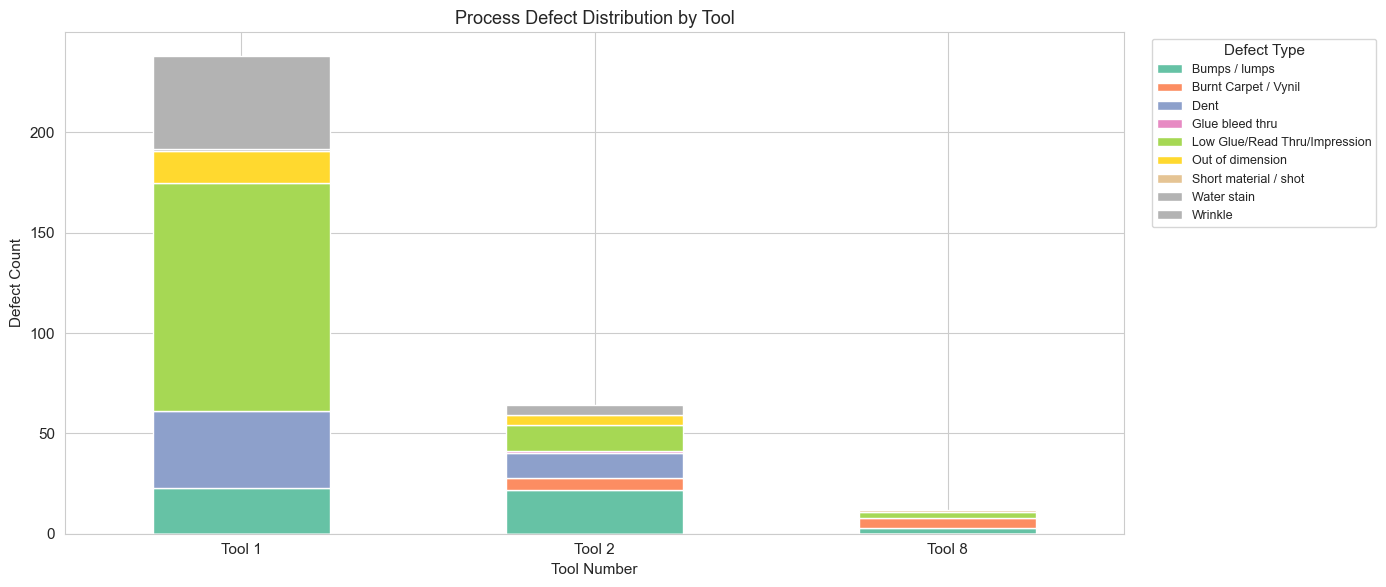

In [24]:
# Defect type by tool visualization
tool_defect = df[df['defect_scope']=='Process Defect'].groupby(['Tool Number', 'description']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
tool_defect.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_title('Process Defect Distribution by Tool')
ax.set_xlabel('Tool Number')
ax.set_ylabel('Defect Count')
ax.set_xticklabels([f'Tool {int(x)}' for x in tool_defect.index], rotation=0)
ax.legend(title='Defect Type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('10_defects_by_tool.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Summary: Recommended Operating Windows

Target values are based on the **median of good-quality parts**. Safe range is the 5th–95th percentile of good parts.

In [25]:
summary_params = [
    ('Roll Coating', 'Glue Temp'),
    ('Roll Coating', 'Roller Gap LH'),
    ('Roll Coating', 'Roller Gap RH'),
    ('Oven', 'Temp. THT at Trigger'),
    ('Oven', 'Temp. BHT at Trigger'),
    ('Oven', 'Temp Z1'),
    ('Oven', 'Temp Z2'),
    ('Oven', 'Temp Z3'),
    ('Oven', 'heating time (tens of seconds)'),
    ('Oven', 'Capacity BHT'),
    ('Grippers', 'Stretch Cross Form'),
    ('Grippers', 'Stetch Length Form'),
    ('Vacuum', 'Vacuum Time Tool Cavity A'),
    ('Vacuum', 'Vacuum Time Tool Cavity B'),
    ('Machine', 'Machine Cycle Time'),
    ('Machine', 'Pyro Clean'),
]

print(f"{'Section':<12} {'Parameter':<35} {'Safe Low':>10} {'TARGET':>10} {'Safe High':>10} {'Defects if out of range'}")
print('═' * 120)

defect_associations = {
    'Glue Temp': 'Low Glue, Wrinkle',
    'Roller Gap LH': 'Low Glue, Wrinkle, Dent, Out of Dimension',
    'Roller Gap RH': 'Low Glue, Wrinkle, Dent, Out of Dimension',
    'Temp. THT at Trigger': 'Wrinkle, Bumps',
    'Temp. BHT at Trigger': 'Low Glue, Out of Dimension, Bumps',
    'Temp Z1': 'Wrinkle, Low Glue',
    'Temp Z2': 'Wrinkle, Low Glue',
    'Temp Z3': 'Wrinkle, Low Glue',
    'heating time (tens of seconds)': 'Wrinkle, Bumps',
    'Capacity BHT': 'Out of Dimension, Low Glue',
    'Stretch Cross Form': 'Low Glue, Wrinkle, Dent, Out of Dimension',
    'Stetch Length Form': 'Low Glue, Wrinkle',
    'Vacuum Time Tool Cavity A': 'Low Glue, Wrinkle',
    'Vacuum Time Tool Cavity B': 'Low Glue, Wrinkle',
    'Machine Cycle Time': 'Bumps, Low Glue',
    'Pyro Clean': 'Dent'
}

for section, param in summary_params:
    if param in good_windows:
        w = good_windows[param]
        assoc = defect_associations.get(param, '')
        print(f"{section:<12} {param:<35} {w['p5']:>10.1f} {w['median']:>10.1f} {w['p95']:>10.1f} {assoc}")

Section      Parameter                             Safe Low     TARGET  Safe High Defects if out of range
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Roll Coating Glue Temp                                144.0      155.0      157.0 Low Glue, Wrinkle
Roll Coating Roller Gap LH                              4.0       19.0       24.0 Low Glue, Wrinkle, Dent, Out of Dimension
Roll Coating Roller Gap RH                              4.0       18.0       22.0 Low Glue, Wrinkle, Dent, Out of Dimension
Oven         Temp. THT at Trigger                     140.0      160.0      180.0 Wrinkle, Bumps
Oven         Temp. BHT at Trigger                     157.7      186.0      205.0 Low Glue, Out of Dimension, Bumps
Oven         Temp Z1                                  116.0      144.0      174.0 Wrinkle, Low Glue
Oven         Temp Z2                                  111.7      139.0      169.0 Wrinkle, Low Glue
Oven        

---
## 11. Conclusion & Next Steps

### Key Findings

1. **8.15% overall scrap rate** with **314 process-related defects** across 4,283 parts (~\$21K/month loss)

2. **Tool #1 is the dominant problem** — 16.5% scrap rate vs 2.7% for Tools #2 and #8. Tool #1 accounts for 76% of all process scrap.

3. **Top 4 defects** (Low Glue, Wrinkle, Dent, Bumps) account for **89%** of process scrap, all with clear parameter signatures.

4. **MAP POCKET parts** have the highest scrap rates (up to 32%) — likely due to their geometric complexity requiring tighter process control.

### Strongest Parameter Signals (Actionable)

| Rank | Parameter | Deviation Pattern | Associated Defects |
|------|-----------|-------------------|-------------------|
| 1 | **Roller Gap (LH/RH)** | 45–65% narrower in scrap | Low Glue, Wrinkle, Dent, Out of Dim |
| 2 | **Temp BHT at Trigger** | 6–11% lower in scrap | Low Glue, Out of Dim, Bumps |
| 3 | **Stretch Cross Form** | 35–47% higher in scrap | Wrinkle, Low Glue, Dent, Out of Dim |
| 4 | **Zone Temps (Z1-Z3)** | 6–14% lower in scrap | Wrinkle, Low Glue |
| 5 | **Machine Cycle Time** | 50–158% higher in scrap | Bumps, Low Glue |
| 6 | **Glue Temp** | 2–4% lower in scrap | Low Glue, Wrinkle |
| 7 | **Pyro Clean** | 36% lower for Dent scrap | Dent (tool contamination) |

### Recommended Approach

1. **Immediate**: Investigate Tool #1 calibration — its scrap rate is 6x the others
2. **Short-term**: Deploy the recommendation engine (Section 8) as a live diagnostic tool — when scrap is detected, show operators which parameters are out of window and what to adjust
3. **Medium-term**: Build part-type-specific operating windows (MAP POCKET recipes need dedicated tuning)
4. **Long-term**: Continuous monitoring dashboard with parameter drift alerts before scrap occurs